### Round 3 Analysis - HYDROGEL_PACK

In [1]:
import os
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import scipy.stats as stats

from pathlib import Path
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.stattools import jarque_bera

import prosperity4
from prosperity4.utils.statistics_utils import compute_returns
from prosperity4.utils.dataloader import (
    load_trading_data,
    get_product_data,
    get_day_data,
    get_product_day_data,
    get_price_data,
    get_order_book_data,
    get_volume_data,
    convert_timestamp,
)


plt.style.use("dark_background")
sns.set_palette("pastel")

### Data Loading

In [2]:
REPO_ROOT = Path(prosperity4.__file__).parents[1]
DATA_FOLDER = REPO_ROOT / "prosperity4" / "round3" / "data"
ROUND_NUM = 3
DAYS = [0, 1, 2]

data = load_trading_data(DATA_FOLDER, ROUND_NUM, DAYS)
prices_df = data.get("prices")
trades_df = data.get("trades")

print("Prices Shape :", prices_df.shape if prices_df is not None else None)
print("Trades Shape :", trades_df.shape if trades_df is not None else None)
print("\n--- Prices Head ---")
display(prices_df.head())
print("\n--- Trades Head ---")
display(trades_df.head())

Prices Shape : (360000, 17)
Trades Shape : (4048, 8)

--- Prices Head ---


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,0,0,VEV_5400,22,25,NaN,NaN,NaN,NaN,24,25,NaN,NaN,NaN,NaN,23.0,0.0
1,0,0,VEV_6500,0,16,NaN,NaN,NaN,NaN,1,16,NaN,NaN,NaN,NaN,0.5,0.0
2,0,0,VEV_5500,8,25,NaN,NaN,NaN,NaN,9,25,NaN,NaN,NaN,NaN,8.5,0.0
3,0,0,VEV_5200,100,19,NaN,NaN,NaN,NaN,103,6,104.0,13.0,NaN,NaN,101.5,0.0
4,0,0,VEV_5300,52,6,51.0,19.0,NaN,NaN,54,25,NaN,NaN,NaN,NaN,53.0,0.0



--- Trades Head ---


,timestamp,buyer,seller,symbol,currency,price,quantity,day
0,2500,NaN,NaN,VELVETFRUIT_EXTRACT,XIRECS,5250.0,4,0
1,2900,NaN,NaN,VEV_5400,XIRECS,22.0,3,0
2,2900,NaN,NaN,VEV_5500,XIRECS,8.0,3,0
3,2900,NaN,NaN,VEV_6000,XIRECS,0.0,3,0
4,2900,NaN,NaN,VEV_6500,XIRECS,0.0,3,0


### Splitting the datasets based on the products

In [3]:
products = prices_df["product"].unique()

osmium_prices_df = prices_df[prices_df["product"] == "HYDROGEL_PACK"]
osmium_trades_df = trades_df[trades_df["symbol"] == "HYDROGEL_PACK"]

In [4]:
"""
Here we are copying the original dataframes, removing the buyer, seller and currency from the trades, summing if there are orders at the
same timestamp and price, then renaming the price and quantity column to market order price and quantity so we know these are bots trades,
then we are merging the 2 datasets so we have all the data on prices and volume, if at that timestamp there's a bot's trade, there's also the 
data for these trades.
At the end we are converting the timestamps so we have timestamp as index
"""

osmium_trades = osmium_trades_df.copy()

# Grouping and merging the ASH_COATED_OSMIUM so we only have 1 dataset containing both prices and trades, sorted by timestamp
osmium_trades = osmium_trades.drop(columns = ["buyer", "seller", "currency"])
osmium_trades = osmium_trades.groupby(["timestamp", "price", "day"], as_index = False).agg({"quantity": "sum"})
osmium_trades = osmium_trades.rename(columns = { 
                                        "price": "market order price",
                                        "quantity": "market order quantity"})
osmium = osmium_prices_df.merge(osmium_trades[["timestamp", "market order price", "market order quantity", "day"]],
                                on = ["timestamp", "day"],
                                how = "left")

# Convert to continuous timeframe so we don't have 2 separate days
osmium = convert_timestamp(osmium)

osmium.head()


,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,market order price,market order quantity,t
0,HYDROGEL_PACK,9992,15,9990.0,30.0,NaN,NaN,10008,15,10010.0,30.0,NaN,NaN,10000.0,0.0,NaN,NaN,-1000000
1,HYDROGEL_PACK,9992,13,9990.0,30.0,NaN,NaN,10008,13,10011.0,30.0,NaN,NaN,10000.0,0.0,NaN,NaN,-999900
2,HYDROGEL_PACK,9995,13,9992.0,21.0,NaN,NaN,10011,13,10013.0,21.0,NaN,NaN,10003.0,0.0,NaN,NaN,-999800
3,HYDROGEL_PACK,9994,11,9992.0,23.0,NaN,NaN,10010,11,10013.0,23.0,NaN,NaN,10002.0,0.0,NaN,NaN,-999700
4,HYDROGEL_PACK,9995,13,9993.0,23.0,NaN,NaN,10011,13,10014.0,23.0,NaN,NaN,10003.0,0.0,NaN,NaN,-999600


# Price and Trades plots

C:\Users\david\AppData\Local\Temp\ipykernel_6344\2494218286.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


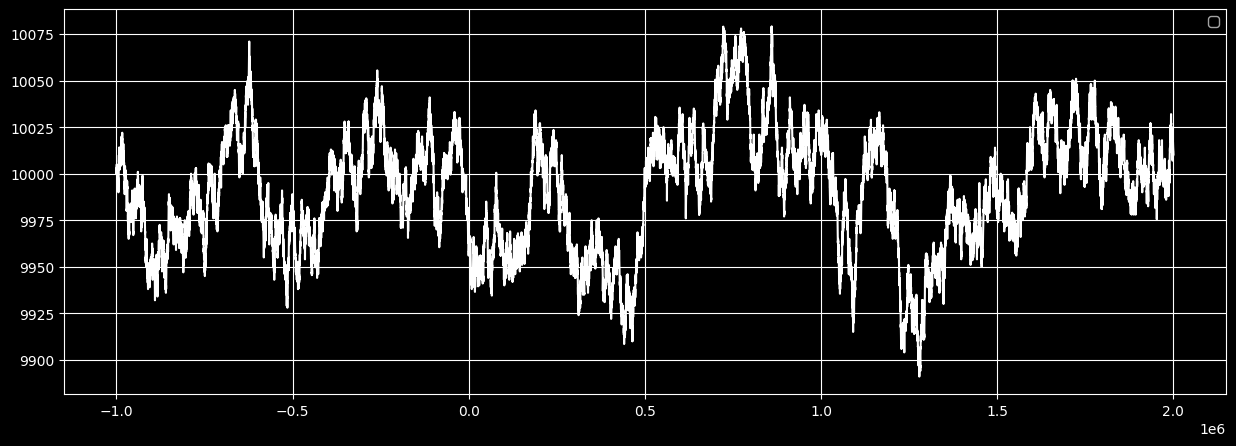

In [7]:
# PLOTS OF PRICES
plt.figure(figsize = (15,5))
plt.plot(osmium["t"], osmium["mid_price"], color = "white")
plt.grid(True)
plt.legend()
plt.show()

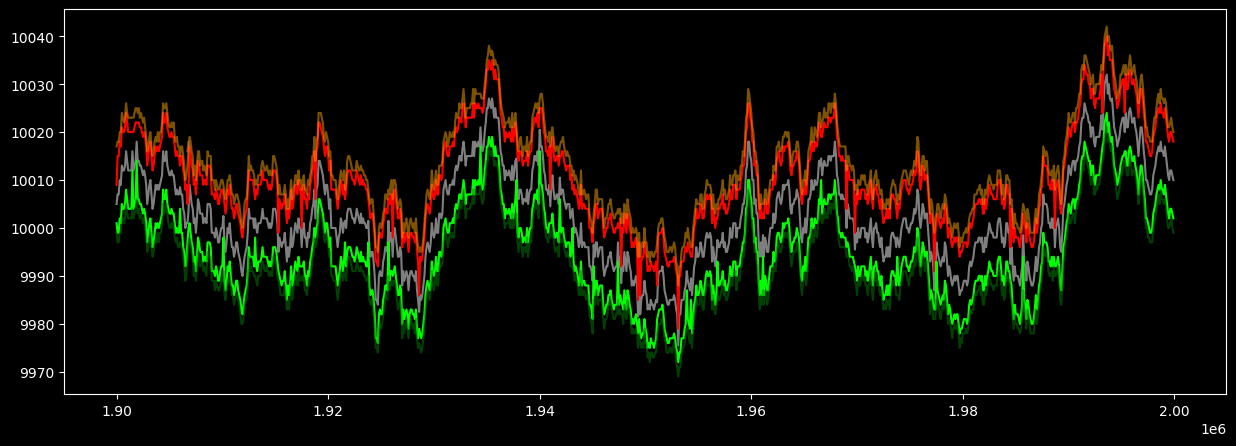

In [8]:
plt.figure(figsize=(15,5))
plt.plot(osmium["t"][-1000:], osmium["mid_price"][-1000:].replace(0, np.nan), color = "white", alpha = 0.5)
plt.plot(osmium["t"][-1000:], osmium["ask_price_1"][-1000:].replace(0, np.nan), color = "red", alpha = 1)
plt.plot(osmium["t"][-1000:], osmium["ask_price_2"][-1000:].replace(0, np.nan), color = "orange", alpha = 0.5)
plt.plot(osmium["t"][-1000:], osmium["ask_price_3"][-1000:].replace(0, np.nan), color = "salmon", alpha = 0.5)
plt.plot(osmium["t"][-1000:], osmium["bid_price_1"][-1000:].replace(0, np.nan), color = "lime", alpha = 1)
plt.plot(osmium["t"][-1000:], osmium["bid_price_2"][-1000:].replace(0, np.nan), color = "green", alpha = 0.5)
plt.plot(osmium["t"][-1000:], osmium["bid_price_3"][-1000:].replace(0, np.nan), color = "darkgreen", alpha = 0.5)
plt.show()

### KALMAN FILTER FV AND Z SCORE

In [13]:
# Kalman Filter — adds 'kalman_fv' column, then smooths into 'fv' (SMA-10 of kalman_fv)
# Parameters (same as the trading bot)
Q = 2.0       # Process noise
R = 10.0      # Measurement noise
P_INIT = 100.0

mid = osmium["mid_price"].replace(0, np.nan).values
n = len(mid)
kalman = np.full(n, np.nan)

x, P = None, P_INIT

for i in range(n):
    if np.isnan(mid[i]):
        if x is not None:
            P += Q  # predict only, uncertainty grows
            kalman[i] = x
        continue

    if x is None:
        x = mid[i]  # initialize
    else:
        P_pred = P + Q
        K = P_pred / (P_pred + R)
        x = x + K * (mid[i] - x)
        P = (1 - K) * P_pred

    kalman[i] = x

osmium["kalman_fv"] = kalman
osmium["fv"] = osmium["kalman_fv"].rolling(window=10, min_periods=1).mean()

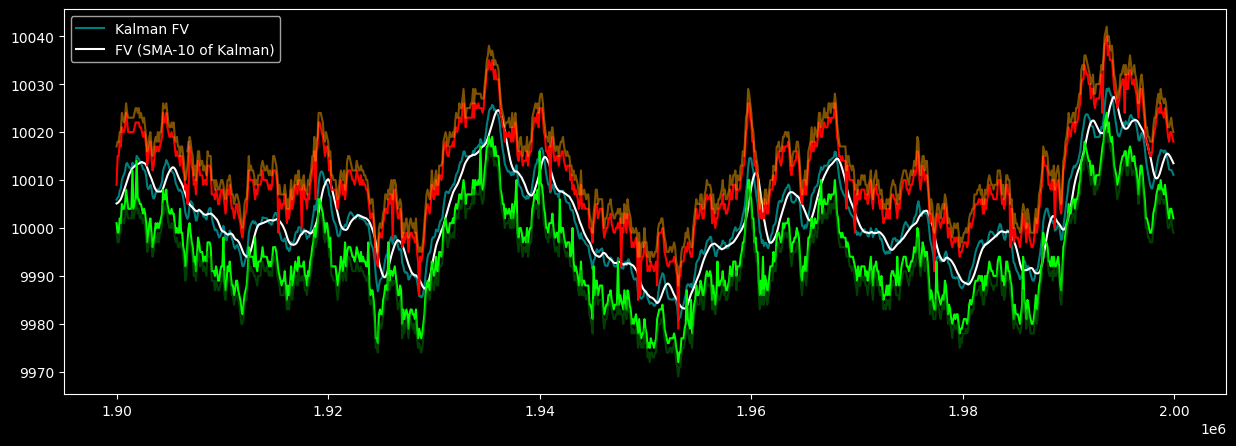

In [14]:
plt.figure(figsize = (15,5))
plt.plot(osmium["t"][-1000:], osmium["kalman_fv"][-1000:], color = "cyan", alpha = 0.5, label = "Kalman FV")
plt.plot(osmium["t"][-1000:], osmium["fv"][-1000:], color = "white", label = "FV (SMA-10 of Kalman)")
plt.plot(osmium["t"][-1000:], osmium["ask_price_1"][-1000:].replace(0, np.nan), color = "red", alpha = 1)
plt.plot(osmium["t"][-1000:], osmium["ask_price_2"][-1000:].replace(0, np.nan), color = "orange", alpha = 0.5)
plt.plot(osmium["t"][-1000:], osmium["ask_price_3"][-1000:].replace(0, np.nan), color = "salmon", alpha = 0.5)
plt.plot(osmium["t"][-1000:], osmium["bid_price_1"][-1000:].replace(0, np.nan), color = "lime", alpha = 1)
plt.plot(osmium["t"][-1000:], osmium["bid_price_2"][-1000:].replace(0, np.nan), color = "green", alpha = 0.5)
plt.plot(osmium["t"][-1000:], osmium["bid_price_3"][-1000:].replace(0, np.nan), color = "darkgreen", alpha = 0.5)
plt.legend()
plt.show()

In [15]:
# Z-Score of Kalman FV vs its 500-tick rolling SMA
WINDOW = 500

rolling_mean = osmium["fv"].rolling(window=WINDOW, min_periods=10).mean()
rolling_std  = osmium["fv"].rolling(window=WINDOW, min_periods=10).std()

osmium["zscore"] = (osmium["fv"] - rolling_mean) / rolling_std

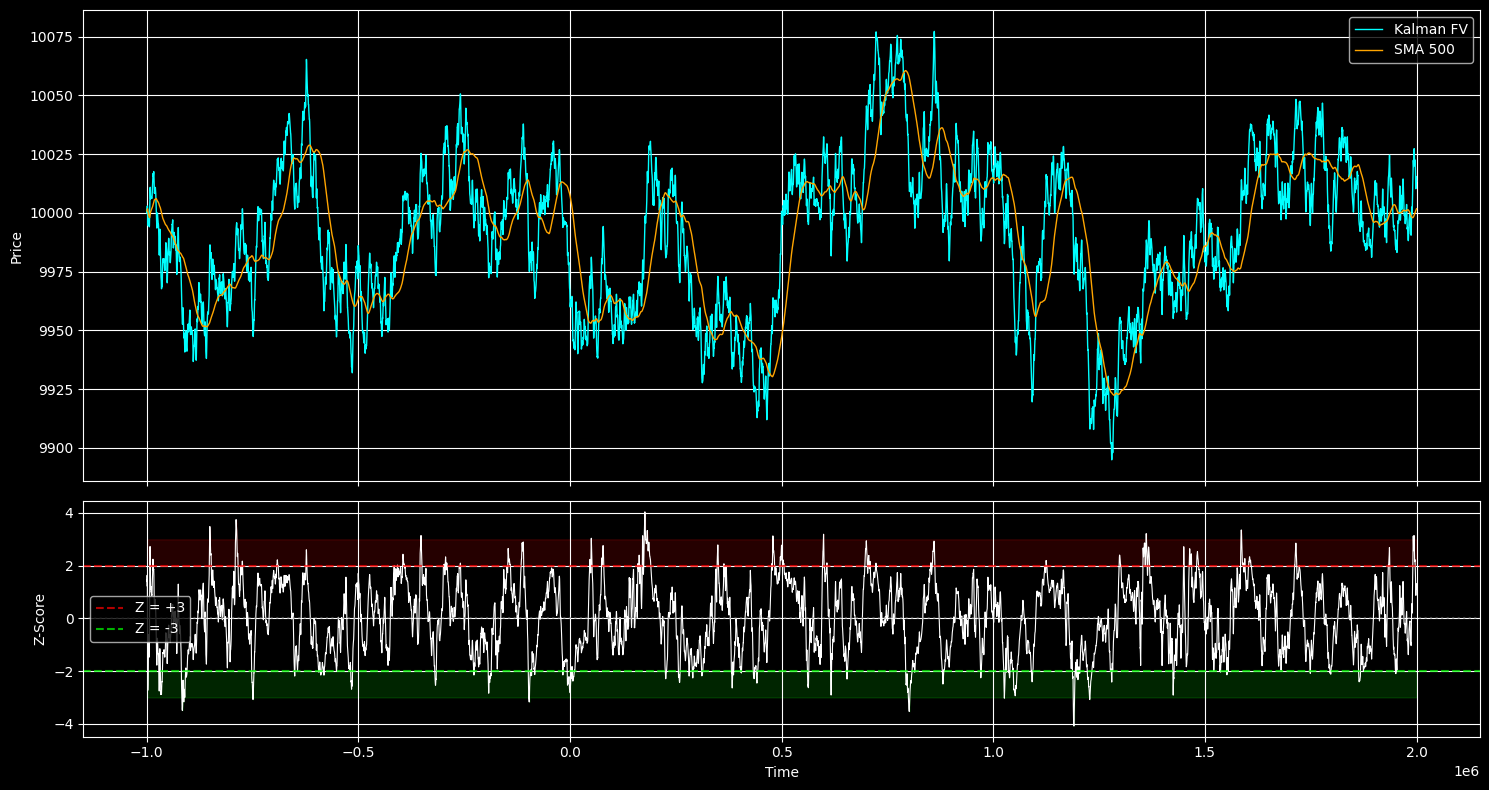

In [16]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]})

ax1.plot(osmium["t"], osmium["fv"], color="cyan", linewidth=1, label="Kalman FV")
ax1.plot(osmium["t"], rolling_mean, color="orange", linewidth=1, label=f"SMA {WINDOW}")
ax1.legend()
ax1.grid(True)
ax1.set_ylabel("Price")

ax2.plot(osmium["t"], osmium["zscore"], color="white", linewidth=0.8)
ax2.axhline( 2, color="red",  linestyle="--", alpha=0.7, label="Z = +3")
ax2.axhline(-2, color="lime", linestyle="--", alpha=0.7, label="Z = -3")
ax2.axhline( 0, color="gray", linestyle=":",  alpha=0.5)
ax2.fill_between(osmium["t"], 2, osmium["zscore"].clip(lower=3), color="red",  alpha=0.15)
ax2.fill_between(osmium["t"], -2, osmium["zscore"].clip(upper=-3), color="lime", alpha=0.15)
ax2.set_ylabel("Z-Score")
ax2.set_xlabel("Time")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [17]:
result = adfuller(osmium['mid_price'])

# take only p-value 
p_value = result[1]

# printing solution 
print(f"The p-value is: {p_value:.4f}")

if p_value < 0.05:
    print("👉 The serie is stationary. Good :) ")
else:
    print("👉 The serie is not stationary. BAD :( )")

The p-value is: 0.0000
👉 The serie is stationary. Good :) 
